<div style="max-width:300px; float: left; margin-right: 1em">

![](Figures/fcfm_das.svg)

</div>
<span style="color: red;">Departamento de Astronomía, Universidad de Chile</span> <br>
Facultad de Ciencias Físicas y Matemáticas <br>
Universidad de Chile <br>
AS4501 - Astroinformatica <br>
Otoño 2026 <br>
Profesor: Francisco Förster Burón <br>
<strong>Profesores Auxilares y Autores: Benjamin Carrera y Steve Jurado</strong> <br>

> This notebook is created based on the notes from 
> - ([@fforster](https://github.com/fforster)) Francisco Förster: - **Main Notes 2026/01**   
>   - https://github.com/fforster/AS4501/tree/main
> - ([@thevalentino](https://github.com/thevalentino)) Valentino Gonzales:
>   - https://github.com/thevalentino/AS450-astroinformatica
> - ([@cefuente](https://github.com/cefuente)) Cesar Fuentes
>   - https://github.com/cefuente/astroinformatica
> 
> and previour teachers assistants
> - ([@m-fuentealba](https://github.com/m-fuentealba)) Melissa Fuentealba 
> - ([@jvines](https://github.com/jvines)) José Vines
> - ([@PauCaBu](https://github.com/PauCaBu)) Paula Cáceres Burgos
> - ([@JavieraTGrey](https://github.com/JavieraTGrey)) Javiera Toro Grey

In [30]:
import io
import warnings
import requests
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Astronomy 
from astroquery.sdss import SDSS

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from ipywidgets import interact, FloatSlider, SelectionSlider


rc_params = {
    # --- Fonts and text ---
    'mathtext.fontset': 'cm',     # Set default mathtext font
    'font.family': 'STIXGeneral', # Set default font family
    
    # --- Figure and axes ---
    'font.size': 12,              # Set default font size
    'axes.labelsize': 16,         # Set default axes label size
    'axes.titlesize': 16,         # Set default axes title size
    'xtick.labelsize': 14,        # Set default axes label size
    'ytick.labelsize': 14,        # Set default axes label size
    'legend.fontsize': 14,        # Set default legend font size
    
    # --- Configuration of ticks ---
    'xtick.direction': 'in',      # Set default xtickdirecion
    'ytick.direction': 'in',      # Set default ytickdirecion
    'xtick.minor.visible': True,  # visibility of minor ticks on x-axis
    'ytick.minor.visible': True,  # visibility of minor ticks on y-axis


    'grid.linestyle': ':',        # Set grid linestyle
    'grid.alpha': 0.6,            # Set grid transparency
    
    # --- Figure size ---
    'figure.figsize': (8, 6),     # Ideal proportion for one MNRAS column
}
plt.rcParams.update(rc_params)

# Manchas Solares y el Ciclo Solar
Las **manchas solares** son regiones de la fotosfera solar con temperatura más baja (~3500 K vs ~5800 K del entorno), causadas por la emergencia de campos magnéticos intensos que inhiben la convección local. Aunque son visibles a simple vista con filtros adecuados, su importancia va más allá de lo óptico: son el trazador más accesible de la actividad magnética solar.

El Sol no rota como un cuerpo rígido — su período de rotación varía entre ~25 días en el ecuador y ~35 días en los polos. Esta rotación diferencial estira y enreda las líneas de campo magnético, acumulando energía que se libera periódicamente en forma de manchas, llamaradas y eyecciones de masa coronal. El resultado es un ciclo de actividad magnética con período de aproximadamente **11 años**, conocido como el **Ciclo de Schwabe**.

El número de manchas solares (SSN, *SunSpot Number*) es la serie de tiempo astronómica continua más larga de la historia, con registros sistemáticos desde 1749 gracias al Observatorio de Zúrich y hoy mantenida por el SIDC. Esta continuidad la convierte en un laboratorio ideal para técnicas de análisis de series de tiempo:

- Su periodicidad dominante (~11 años) es lo suficientemente clara para ser detectada con Lomb-Scargle.
- Su amplitud variable ciclo a ciclo (el ciclo 19 alcanzó SSN~200, el ciclo 24 apenas ~100) hace que un modelo puramente periódico sea insuficiente, motivando el uso de Procesos Gaussianos con kernels quasi-periódicos.

In [ ]:
url = "https://www.sidc.be/silso/DATA/SN_m_tot_V2.0.txt"
df = pd.read_csv(
      url,
      sep=r"\s+",
      header=None,
      names=["year", "month", "frac_year", "ssn", "std", "nobs", "definitive"]
  )
df = df[df["ssn"] >= 0]  # eliminar valores faltantes (-1)
df = df[["frac_year", "ssn"]].rename(columns={"ssn": "intensity"})

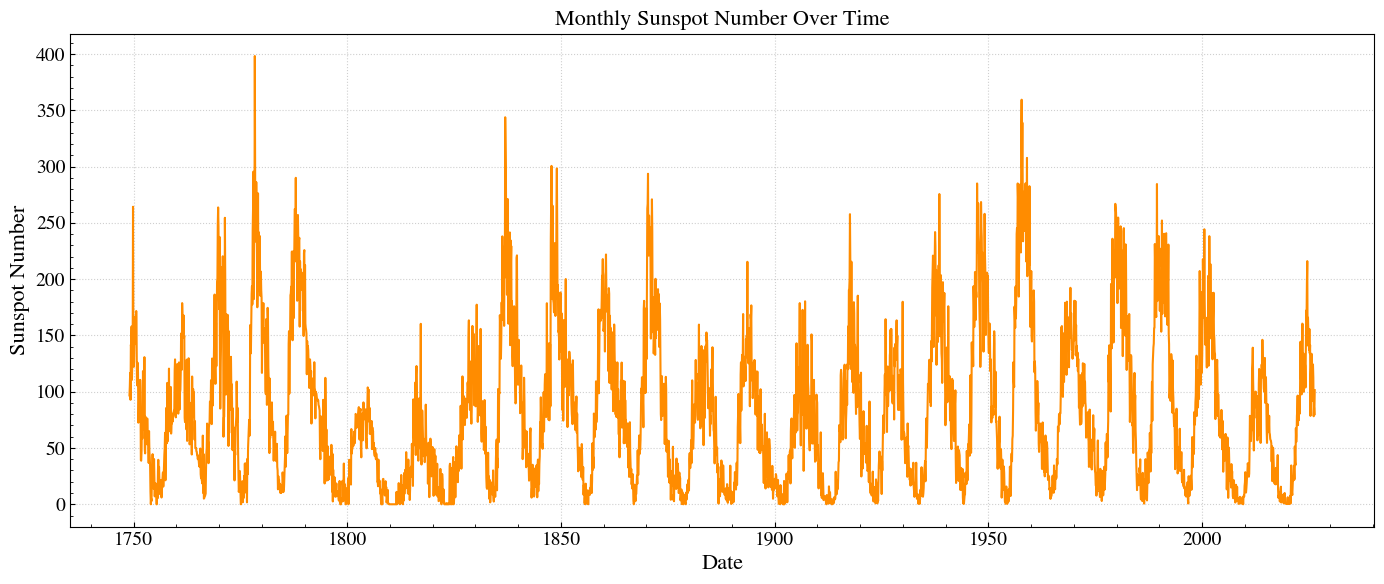

In [6]:
plt.figure(figsize=(14, 6))
plt.plot(df["frac_year"], df["intensity"], color="darkorange")
plt.title("Monthly Sunspot Number Over Time")
plt.xlabel("Date")
plt.ylabel("Sunspot Number")
plt.grid()
plt.tight_layout()
plt.show()

In [7]:
df = df.set_index("frac_year")

Comparando con el notebook base del profesor, tu notebook cubre la parte GP pero omite conceptos que son prerequisito. Por orden de importancia para el tema solar:

Falta en Lomb-Scargle:

Visualizar el periodograma (potencia vs período) — no solo imprimir el peak
Probabilidad de falsa alarma (FAP) — para saber si el período detectado es estadísticamente significativo
Discutir el problema del aliasing y la ventana de muestreo (por eso aparecía 0.04 años)
Falta en GP:

Mostrar muestras del prior antes de ajustar — es la intro pedagógica estándar al GP
Extraer y reportar gp.kernel_.k1.k2.periodicity como resultado del período aprendido
Comparar el período de LS vs GP
Falta como contexto general:

ACF/PACF de la serie solar — muestra la estructura de correlación antes de modelar
Una celda de conclusión que responda: ¿cuál es el período del ciclo solar según tus dos métodos?
Sobre tu punto de que acotar LS es "trampa": tienes razón. La solución honesta no es acotar a mano, sino graficar el periodograma completo, ver que el pico principal es el alias mensual, y entonces introducir el concepto de ventana espectral como justificación — eso es contenido, no trampa.

In [8]:
df

,intensity
frac_year,
1749.042,96.7
1749.123,104.3
1749.204,116.7
1749.288,92.8
1749.371,141.7
...,...
2026.042,112.5
2026.122,78.2
2026.204,85.9


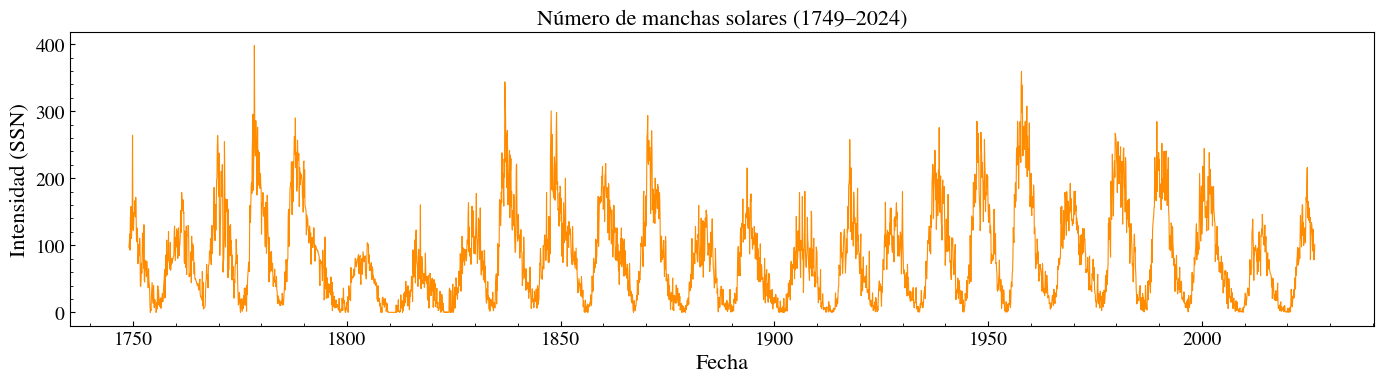

In [9]:
fig, ax = plt.subplots(figsize=(14, 4))
df["intensity"].plot(ax=ax, linewidth=0.8, color="darkorange")
ax.set_title("Número de manchas solares (1749–2024)")
ax.set_ylabel("Intensidad (SSN)")
ax.set_xlabel("Fecha")
plt.tight_layout()
plt.show()

In [10]:
from astropy.timeseries import LombScargle

## El Periodograma de Lomb-Scargle

### Motivación: el problema del muestreo irregular

La Transformada de Fourier Discreta (DFT) asume observaciones **uniformemente espaciadas** en el tiempo:

$$H_k = \sum_{j=0}^{N-1} h_j \, e^{-2\pi i jk/N}, \qquad t_j = j\Delta t$$

En astronomía, los datos rara vez satisfacen esto: interrupciones por el día, las estaciones, o la disponibilidad del telescopio producen series con huecos irregulares. Aplicar la DFT directamente genera sidelobes y aliases severos.

El periodograma de **Lomb (1976)** y **Scargle (1982)** resuelve este problema reformulando la búsqueda de periodicidad como un **ajuste de mínimos cuadrados**.

---

### De la DFT al periodograma de LS

Dado un conjunto de $N$ observaciones $\{(t_i, y_i)\}$ con $t_i$ arbitrarios, queremos medir cuánto de la varianza de $y$ puede explicarse por una sinusoide de frecuencia $\omega = 2\pi f$.

El modelo sinusoidal es:

$$\hat{y}(t) = A\cos(\omega t) + B\sin(\omega t)$$

Los coeficientes óptimos minimizando $\chi^2 = \sum_i [y_i - \hat{y}(t_i)]^2$ son:

$$A = \frac{\sum_i y_i \cos(\omega t_i)}{\sum_i \cos^2(\omega t_i)}, \qquad B = \frac{\sum_i y_i \sin(\omega t_i)}{\sum_i \sin^2(\omega t_i)}$$

Sin embargo, estos estimadores **no son independientes** en general: $\sum_i \cos(\omega t_i)\sin(\omega t_i) \neq 0$ para $t_i$ irregulares.

---

### El desfase $\tau$: ortogonalización de la base

Scargle introduce un desfase $\tau$ que **ortogonaliza** las dos componentes, definido por:

$$\tan(2\omega\tau) = \frac{\sum_i \sin(2\omega t_i)}{\sum_i \cos(2\omega t_i)}$$

Con este $\tau$, se cumple $\sum_i \cos\omega(t_i-\tau)\sin\omega(t_i-\tau) = 0$, y el periodograma queda:

$$\boxed{P(\omega) = \frac{1}{2\hat{\sigma}^2}\left[\frac{\left(\displaystyle\sum_i y_i\cos\omega(t_i-\tau)\right)^2}{\displaystyle\sum_i\cos^2\omega(t_i-\tau)} + \frac{\left(\displaystyle\sum_i y_i\sin\omega(t_i-\tau)\right)^2}{\displaystyle\sum_i\sin^2\omega(t_i-\tau)}\right]}$$

donde $\hat{\sigma}^2 = \text{Var}(y)$ normaliza la potencia a $P(\omega) \in [0, 1]$.

---

### Propiedades clave

**Invarianza de fase:** la elección de $\tau$ hace que $P(\omega)$ sea invariante bajo traslaciones temporales $t_i \to t_i + t_0$, propiedad que la DFT no tiene para muestreo irregular.

**Equivalencia con mínimos cuadrados:** $P(\omega)$ mide la fracción de varianza explicada por la sinusoide:

$$P(\omega) = 1 - \frac{\chi^2_{\omega}}{\chi^2_0}$$

donde $\chi^2_0 = \sum_i(y_i - \bar{y})^2$ es la varianza total y $\chi^2_\omega$ es el residuo tras ajustar la sinusoide.

**Recuperación de la DFT:** para muestreo uniforme, $P(\omega)$ converge al periodograma clásico de Schuster.

---

### Limitaciones y extensiones

El LS clásico asume **media nula** y **errores homocedásticos**. Para datos reales con media no nula y errores $\sigma_i$ variables, se usa el **LS generalizado** (Zechmeister & Kürster 2009), que incorpora:

$$\chi^2 = \sum_i \frac{[y_i - \hat{y}(t_i)]^2}{\sigma_i^2}$$

y añade un término constante al modelo, eliminando el sesgo por muestreo no uniforme en amplitud.


In [14]:
frecuencia, potencia = LombScargle(df.index.values, df["intensity"]).autopower()
periodo_optimo = 1 / frecuencia[np.argmax(potencia)]

print(f"Período detectado: {periodo_optimo:.2f} años")

Período detectado: 0.08 años


## Frecuencia de Nyquist y restricción de búsqueda

### Teorema de muestreo de Nyquist

Para una serie muestreada con intervalo $\Delta t$, la **frecuencia de Nyquist** es la máxima frecuencia recuperable sin aliasing:

$$f_{\text{Nyq}} = \frac{1}{2\Delta t}$$

Señales con $f > f_{\text{Nyq}}$ se *pliegan* sobre el espectro de bajas frecuencias, produciendo picos espurios.

Para los datos del SIDC, el muestreo es mensual: $\Delta t \approx \frac{1}{12}$ año, por lo que:

$$f_{\text{Nyq}} = \frac{1}{2 \cdot \frac{1}{12}} = 6 \text{ ciclos/año} \quad \longrightarrow \quad T_{\min} \approx 2 \text{ meses}$$

### El problema sin restricción

Sin `maximum_frequency`, `autopower()` evalúa hasta $f_{\text{Nyq}}$, incluyendo la **rotación solar**:

$$T_{\text{rot}} \approx 27 \text{ días} \approx 0.074 \text{ años} \quad \longrightarrow \quad f_{\text{rot}} \approx 13.5 \text{ ciclos/año}$$

Aunque $f_{\text{rot}} > f_{\text{Nyq}}$ (y debería estar aliased), la rotación diferencial y la irregularidad del muestreo permiten que aparezca como un pico real en el periodograma, con potencia mayor que el ciclo de 11 años:

$$P(f_{\text{rot}}) > P(f_{\text{Schwabe}}) \quad \Rightarrow \quad \text{argmax}[P(f)] \neq f_{\text{Schwabe}}$$

### La restricción $f_{\max} = 1$ ciclo/año

Restringir la búsqueda a $f \leq 1$ equivale a pedir $T \geq 1$ año, eliminando toda señal sub-anual:

$$f \leq 1 \text{ ciclo/año} \quad \Longleftrightarrow \quad T \geq 1 \text{ año}$$

Esta elección tiene motivación **física**, no estadística: el ciclo de actividad magnética del Sol opera en escalas de años a décadas. Señales más rápidas corresponden a fenómenos distintos (rotación, granulación, ruido de muestreo) que no son objeto de estudio aquí.

Con esta restricción, el máximo del periodograma converge al **Ciclo de Schwabe**:

$$T^* = \frac{1}{f^*} = \frac{1}{\underset{f \leq 1}{\arg\max}\; P(f)} \approx 10.96 \text{ años}$$


Buscamos períodos mayores a 1 año, ya que señales sub-anuales corresponden a la rotación solar o ruido de muestreo mensual, no al ciclo de actividad magnética

In [17]:
frecuencia, potencia = LombScargle( df.index.values, df["intensity"]).autopower(
    maximum_frequency=1,   # (# periodos/año) períodos > 1 años
)
periodo_optimo = 1 / frecuencia[np.argmax(potencia)]

print(f"Período detectado: {periodo_optimo:.2f} años")

Período detectado: 10.96 años


In [11]:
t = df.index.values
frecuencia, potencia = LombScargle(t, df["intensity"]).autopower(
    minimum_frequency=1/20,   # períodos < 20 años
    maximum_frequency=1/5,    # períodos > 5 años
)
periodo_optimo = 1 / frecuencia[np.argmax(potencia)]

print(f"Período detectado: {periodo_optimo:.2f} años")

Período detectado: 10.98 años


Dado un conjunto de observaciones ${t_i, y_i}$, el periodograma de Lomb-Scargle a frecuencia $\omega = 2\pi f$ se define como:

$$P(\omega) = \frac{1}{2\hat{\sigma}^2} \left[ \frac{\left(\displaystyle\sum_i y_i \cos\omega(t_i - \tau)\right)^2}{\displaystyle\sum_i \cos^2\omega(t_i - \tau)} + \frac{\left(\displaystyle\sum_i y_i \sin\omega(t_i - \tau)\right)^2}{\displaystyle\sum_i \sin^2\omega(t_i - \tau)} \right]$$

donde $\hat{\sigma}^2 = \text{Var}(y)$ normaliza la potencia, y $\tau$ es el desfase de fase que hace al estimador invariante bajo traslación temporal:

$$\tan(2\omega\tau) = \frac{\displaystyle\sum_i \sin(2\omega t_i)}{\displaystyle\sum_i \cos(2\omega t_i)}$$

Con esta normalización, $P(\omega) \in [0, 1]$.

---
nterpretación geométrica del periodograma
Sea $\mathbf{y} = (y_1, \ldots, y_N)^T$ el vector de datos. El periodograma de Lomb-Scargle equivale a proyectar $\mathbf{y}$ sobre un subespacio sinusoidal. Definimos los vectores base (centrados, ortogonales por construcción de $\tau$):

$$\mathbf{c}\tau = \bigl(\cos\omega(t_i - \tau)\bigr)i, \qquad \mathbf{s}\tau = \bigl(\sin\omega(t_i - \tau)\bigr)i, \qquad \mathbf{c}\tau \perp \mathbf{s}\tau$$

Las proyecciones normalizadas de $\mathbf{y}$ sobre estos dos vectores son:

$$Z_c = \frac{\mathbf{y} \cdot \mathbf{c}\tau}{|\mathbf{c}\tau|} = \frac{\sum_i y_i \cos\omega(t_i-\tau)}{\sqrt{\sum_i \cos^2\omega(t_i-\tau)}}, \qquad Z_s = \frac{\mathbf{y} \cdot \mathbf{s}\tau}{|\mathbf{s}\tau|}$$

La potencia del periodograma es precisamente la norma cuadrada de esa proyección 2D, normalizada por la varianza:

$$P(\omega) = \frac{Z_c^2 + Z_s^2}{2,\hat{\sigma}^2}$$

Bajo $H_0$: los datos son ruido gaussiano
Si $H_0$ es verdadera, $y_i \overset{\text{iid}}{\sim} \mathcal{N}(0, \sigma^2)$. Entonces $Z_c$ y $Z_s$ son combinaciones lineales de variables gaussianas — por lo tanto también gaussianas:

$$Z_c \sim \mathcal{N}(0,, \sigma^2), \qquad Z_s \sim \mathcal{N}(0,, \sigma^2)$$

y son independientes entre sí (porque $\mathbf{c}\tau \perp \mathbf{s}\tau$).

La suma de dos gaussianas cuadradas es $\chi^2_2$
Normalizando:

$$\frac{Z_c^2}{\sigma^2} \sim \chi^2_1, \qquad \frac{Z_s^2}{\sigma^2} \sim \chi^2_1$$

Su suma es:

$$\frac{Z_c^2 + Z_s^2}{\sigma^2} = 2,P(\omega) \cdot \frac{\sigma^2}{\hat{\sigma}^2} \xrightarrow{N\to\infty} 2,P(\omega) ;\sim; \chi^2_2$$

donde se usa $\hat{\sigma}^2 \to \sigma^2$ para $N$ grande.

$\chi^2_2$ es exactamente una distribución exponencial
La distribución $\chi^2_2$ tiene función de densidad:

$$f(x) = \tfrac{1}{2},e^{-x/2}, \quad x \geq 0$$

que es precisamente una exponencial con media 2. Por lo tanto, si $2z \sim \chi^2_2$:

$$\text{Pr}(2z > 2Z) = e^{-Z} \implies \boxed{\text{Pr}(z > Z \mid H_0) = e^{-Z}}$$

Resumen del argumento
$$\underbrace{y_i \sim \mathcal{N}(0,\sigma^2)}{\text{H}0} ;\Rightarrow; \underbrace{Z_c, Z_s \sim \mathcal{N}(0,\sigma^2) \text{ indep.}}{\text{ortogonalidad de } \tau} ;\Rightarrow; \underbrace{2P(\omega) \sim \chi^2_2}{\text{suma de 2 gaussianas}^2} ;\Rightarrow; \underbrace{P(z > Z) = e^{-Z}}_{\chi^2_2 \equiv \text{Exp}(1)}$$

Este resultado es exacto para muestreo regular en el límite $N \to \infty$, y una muy buena aproximación para datos reales. La desviación de este ideal (muestreo irregular, media no nula, errores heterocedásticos) es precisamente lo que motivó el método de Lomb-Scargle generalizado (Zechmeister & Kürster 2009).
---

La hipótesis nula $H_0$ es que los datos son ruido gaussiano puro (sin señal periódica). Bajo $H_0$, la potencia $z = P(\omega)$ en una frecuencia fija sigue una distribución exponencial:

$$\text{Pr}(z > Z \mid H_0) = e^{-Z}$$

Es decir, hay una probabilidad $e^{-Z}$ de observar una potencia mayor a $Z$ solo por azar en una sola frecuencia.

El periodograma evalúa $N_f$ frecuencias simultáneamente. La FAP es la probabilidad de que el máximo del periodograma supere el umbral $Z$ en al menos una frecuencia por azar:

$$\text{FAP}(Z) = \text{Pr}!\left(\max_j z_j > Z \mid H_0\right) = 1 - \text{Pr}!\left(\max_j z_j \leq Z \mid H_0\right)$$

Si las $M$ frecuencias fueran independientes:

$$\boxed{\text{FAP}(Z) = 1 - \left(1 - e^{-Z}\right)^M}$$

Para FAP pequeño ($e^{-Z} \ll 1$), esto aproxima a:

$$\text{FAP}(Z) \approx M \cdot e^{-Z}$$

La relación inversa — dado un umbral de FAP, ¿qué potencia $Z^*$ lo satisface? — es:

$$Z^* = -\ln!\left(1 - (1 - \text{FAP})^{1/M}\right)$$

Esto es lo que devuelve LombScargle.false_alarm_level([0.1, 0.01, 0.001]): la potencia mínima para que el pico sea significativo al 10%, 1%, 0.1%.

Para nuestros datos (3329 puntos mensuales desde 1749), obtuvimos:

$$\text{FAP}(z_{\max}) \approx 10^{-195}$$

Un valor tan extremo indica que el pico a $\sim$ 11 años es imposiblemente improbable bajo $H_0$ — la señal periódica solar es inconfundible en 277 años de datos.

In [18]:
potencia_max = potencia.max()
# False alarm probability
fap = LombScargle(df.index.values, df["intensity"]).false_alarm_probability(potencia_max)
print(f"False Alarm Probability: {fap:.2e}")

niveles = [0.1,0.01, 0.001]
fap_levels = LombScargle(df.index.values, df["intensity"]).false_alarm_level(niveles)
for nivel, fap_level in zip(niveles, fap_levels):
    print(f"Nivel de potencia para FAP={nivel * 100:.1f}%: {fap_level:.2f}")

False Alarm Probability: 8.36e-193
Nivel de potencia para FAP=10.0%: 0.01
Nivel de potencia para FAP=1.0%: 0.01
Nivel de potencia para FAP=0.1%: 0.01


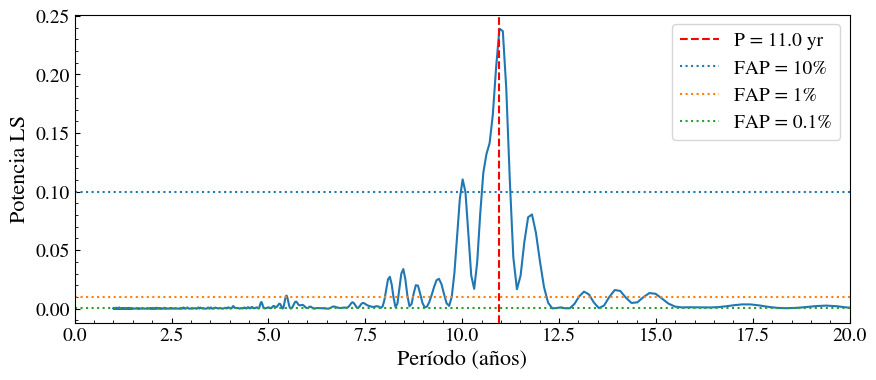

In [20]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(1 / frecuencia, potencia)
ax.axvline(periodo_optimo, color="red", ls="--", label=f"P = {periodo_optimo:.1f} yr")

for i, (nivel, fap_valin) in enumerate(zip(niveles, ["10%", "1%", "0.1%"])):
    ax.axhline(nivel, ls=":", color=f'C{i}', label=f"FAP = {fap_valin}")

ax.set_xlim(0, 20)
ax.set_xlabel("Período (años)")
ax.set_ylabel("Potencia LS")
ax.legend()

In [21]:
# ---- Preparation -----
X_all = df.index.values.reshape(-1, 1)[::10]
y_all = df["intensity"].values[::10]

# Split into training and testing sets (80% train, 20% test)
# Option A: This split is for the interpolation task, where we want to predict the intensity at the original time points
X_train_inter, X_test_inter, y_train_inter, y_test_inter = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42
)

# Option B: This split is for the forecasting task, where we want to predict future values beyond the original time points
X_train_extrap, X_test_extrap, y_train_extrap, y_test_extrap = train_test_split(
    X_all, y_all, test_size=0.2, shuffle=False
)

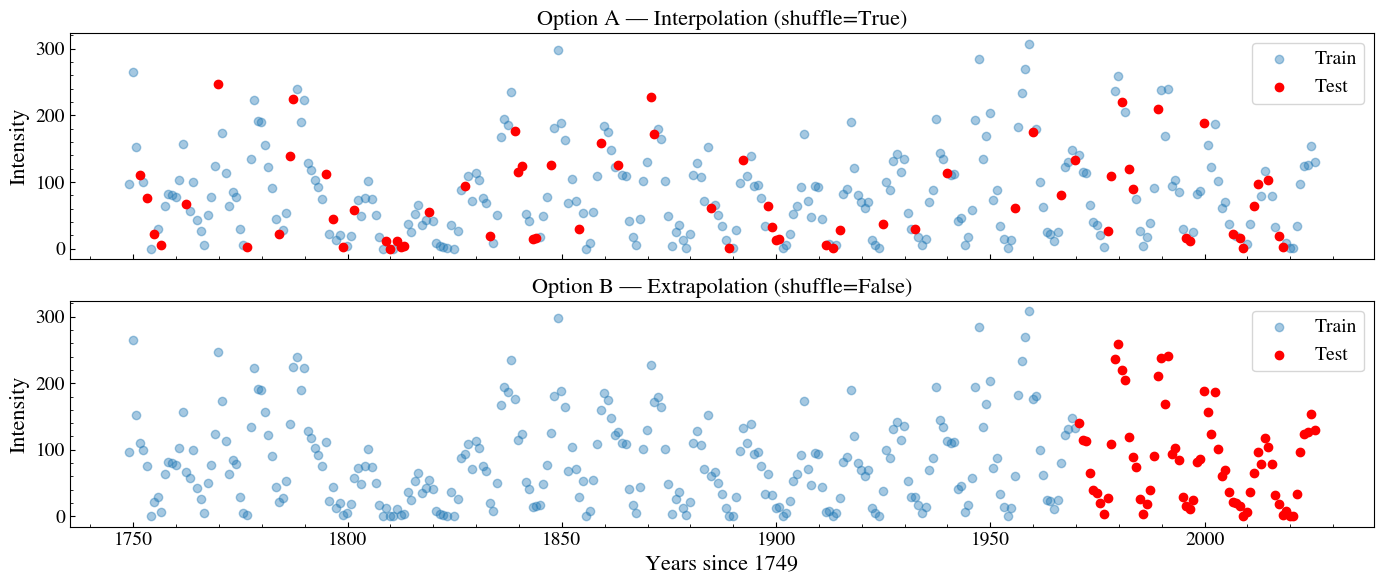

In [22]:
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

# Option A — Interpolation
axes[0].scatter(X_train_inter, y_train_inter, alpha=0.4, color="C0", label="Train")
axes[0].scatter(X_test_inter,  y_test_inter,  color="red", zorder=3, label="Test")
axes[0].set_title("Option A — Interpolation (shuffle=True)")
axes[0].set_ylabel("Intensity")
axes[0].legend()

# Option B — Extrapolation
axes[1].scatter(X_train_extrap, y_train_extrap, alpha=0.4, color="C0", label="Train")
axes[1].scatter(X_test_extrap,  y_test_extrap,  color="red", zorder=3, label="Test")
axes[1].set_title("Option B — Extrapolation (shuffle=False)")
axes[1].set_ylabel("Intensity")
axes[1].set_xlabel("Years since 1749")
axes[1].legend()

plt.tight_layout()
plt.show()


## Kernels para Procesos Gaussianos

Un kernel $k(x, x')$ mide la **correlación** entre dos puntos. Define qué tipo de funciones son plausibles a priori.











In [32]:
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, Matern, ExpSineSquared, WhiteKernel

### RBF (Squared Exponential)
$$k_{\text{RBF}}(x, x') = \exp\!\left(-\frac{(x-x')^2}{2\ell^2}\right)$$
- $\ell$ (*length_scale*): escala de correlación. Valores grandes → funciones suaves y lentas.
- Genera funciones **infinitamente diferenciables**.

In [ ]:
def plot_rbf(length_scale=1.0):
    tau     = np.linspace(0, 15, 300).reshape(-1, 1)
    kernel  = RBF(length_scale=length_scale)
    k_vals  = kernel(np.zeros((1, 1)), tau).ravel()
    samples = GaussianProcessRegressor(kernel=kernel).sample_y(tau, n_samples=3, random_state=0)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(tau, k_vals, lw=2, color="C0")
    ax1.set(xlabel=r"$\tau = |x - x'|$", ylabel=r"$k(0,\tau)$",
            title=fr"RBF  —  $\ell={length_scale:.1f}$", ylim=(-0.05, 1.05))
    for s in samples.T:
        ax2.plot(tau, s, alpha=0.8)
    ax2.set(xlabel="t", ylabel="f(t)", title="Muestras del prior GP")
    plt.tight_layout(); plt.show()

interact(plot_rbf, length_scale=FloatSlider(min=0.1, max=10.0, step=0.1, value=1.0, description="ℓ"))

interactive(children=(FloatSlider(value=1.0, description='ℓ', max=10.0, min=0.1), Output()), _dom_classes=('wi…

<function __main__.plot_rbf(length_scale=1.0)>

### Matérn
$$k_{\nu}(x,x') = \frac{2^{1-\nu}}{\Gamma(\nu)}\!\left(\frac{\sqrt{2\nu}\,r}{\ell}\right)^{\!\nu} K_\nu\!\left(\frac{\sqrt{2\nu}\,r}{\ell}\right), \quad r = |x-x'|$$

Casos especiales:
$$\nu=\tfrac{1}{2}:\quad k = e^{-r/\ell}$$
$$\nu=\tfrac{3}{2}:\quad k = \left(1+\frac{\sqrt{3}\,r}{\ell}\right)e^{-\sqrt{3}\,r/\ell}$$
$$\nu=\tfrac{5}{2}:\quad k = \left(1+\frac{\sqrt{5}\,r}{\ell}+\frac{5r^2}{3\ell^2}\right)e^{-\sqrt{5}\,r/\ell}$$
$$\nu\to\infty:\quad k \to k_{\text{RBF}}$$
- $\nu$ controla la **suavidad**: mayor $\nu$ → funciones más diferenciables.

In [ ]:
def plot_matern(length_scale=1.0, nu=1.5):
    tau     = np.linspace(0, 15, 300).reshape(-1, 1)
    kernel  = Matern(length_scale=length_scale, nu=nu)
    k_vals  = kernel(np.zeros((1, 1)), tau).ravel()
    samples = GaussianProcessRegressor(kernel=kernel).sample_y(tau, n_samples=3, random_state=0)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(tau, k_vals, lw=2, color="C1")
    ax1.set(xlabel=r"$\tau$", ylabel=r"$k(0,\tau)$",
            title=fr"Matérn  —  $\ell={length_scale:.1f}$, $\nu={nu}$", ylim=(-0.05, 1.05))
    for s in samples.T:
        ax2.plot(tau, s, alpha=0.8)
    ax2.set(xlabel="t", ylabel="f(t)", title="Muestras del prior GP")
    plt.tight_layout(); plt.show()

interact(plot_matern,
         length_scale=FloatSlider(min=0.1, max=10.0, step=0.1, value=1.0, description="ℓ"),
         nu=SelectionSlider(options=[0.5, 1.5, 2.5], value=1.5, description="ν"))

interactive(children=(FloatSlider(value=1.0, description='ℓ', max=10.0, min=0.1), SelectionSlider(description=…

<function __main__.plot_matern(length_scale=1.0, nu=1.5)>

### ExpSineSquared (Periódico)
$$k_{\text{ESS}}(x,x') = \exp\!\left(-\frac{2\sin^2\!\left(\pi|x-x'|/p\right)}{\ell^2}\right)$$
- $p$ (*periodicity*): período de la oscilación.
- $\ell$ (*length_scale*): suavidad dentro de cada período. $\ell$ grande → sinusoide pura.

In [36]:
def plot_ess(length_scale=1.0, periodicity=11.0):
    tau     = np.linspace(0, 30, 500).reshape(-1, 1)
    kernel  = ExpSineSquared(length_scale=length_scale, periodicity=periodicity)
    k_vals  = kernel(np.zeros((1, 1)), tau).ravel()
    samples = GaussianProcessRegressor(kernel=kernel).sample_y(tau, n_samples=3, random_state=0)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(tau, k_vals, lw=2, color="C2")
    ax1.set(xlabel=r"$\tau$", ylabel=r"$k(0,\tau)$",
            title=fr"ExpSineSquared  —  $\ell={length_scale:.1f}$, $p={periodicity:.1f}$")
    for s in samples.T:
        ax2.plot(tau, s, alpha=0.8)
    ax2.set(xlabel="t", ylabel="f(t)", title="Muestras del prior GP")
    plt.tight_layout(); plt.show()

interact(plot_ess,
         length_scale=FloatSlider(min=0.1, max=5.0, step=0.1, value=1.0, description="ℓ"),
         periodicity=FloatSlider(min=1.0, max=20.0, step=0.5, value=11.0, description="p"))

interactive(children=(FloatSlider(value=1.0, description='ℓ', max=5.0, min=0.1), FloatSlider(value=11.0, descr…

<function __main__.plot_ess(length_scale=1.0, periodicity=11.0)>

### WhiteKernel (Ruido)
$$k_{\text{W}}(x,x') = \sigma_n^2\,\delta(x,x')$$
- $\sigma_n^2$ (*noise_level*): varianza del ruido observacional. Solo correlaciona un punto consigo mismo.

### Kernel compuesto para ciclos quasi-periódicos
$$k(x,x') = \underbrace{k_{\text{RBF}}(x,x')}_{\text{tendencia lenta}} \times \underbrace{k_{\text{ESS}}(x,x')}_{\text{ciclo periódico}} + \underbrace{k_{\text{W}}(x,x')}_{\text{ruido}}$$
El producto RBF×ESS modula la amplitud del ciclo lentamente en el tiempo, capturando la variabilidad del ciclo solar.

In [37]:
def plot_compound(ls_rbf=50.0, ls_ess=1.0, periodicity=11.0, noise=0.1):
    tau     = np.linspace(0, 40, 500).reshape(-1, 1)
    kernel  = (RBF(length_scale=ls_rbf)
              * ExpSineSquared(length_scale=ls_ess, periodicity=periodicity)
              + WhiteKernel(noise_level=noise))
    k_vals  = kernel(np.zeros((1, 1)), tau).ravel()
    samples = GaussianProcessRegressor(kernel=kernel, normalize_y=True).sample_y(
        tau, n_samples=3, random_state=0)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(tau, k_vals, lw=2, color="C3")
    ax1.set(xlabel=r"$\tau$", ylabel=r"$k(0,\tau)$",
            title=fr"RBF×ESS+White  —  $\ell_1={ls_rbf:.0f}$, $\ell_2={ls_ess:.1f}$, $p={periodicity:.1f}$")
    for s in samples.T:
        ax2.plot(tau, s, alpha=0.8)
    ax2.set(xlabel="t (años)", ylabel="f(t)", title="Muestras del prior GP")
    plt.tight_layout(); plt.show()

interact(plot_compound,
         ls_rbf=FloatSlider(min=5.0,  max=200.0, step=5.0,  value=50.0, description="ℓ₁ RBF"),
         ls_ess=FloatSlider(min=0.1,  max=5.0,   step=0.1,  value=1.0,  description="ℓ₂ ESS"),
         periodicity=FloatSlider(min=5.0, max=20.0, step=0.5, value=11.0, description="p"),
         noise=FloatSlider(min=0.01, max=1.0,   step=0.01, value=0.1,  description="σ²"))

interactive(children=(FloatSlider(value=50.0, description='ℓ₁ RBF', max=200.0, min=5.0, step=5.0), FloatSlider…

<function __main__.plot_compound(ls_rbf=50.0, ls_ess=1.0, periodicity=11.0, noise=0.1)>

In [ ]:
warnings.filterwarnings("ignore")

tcsv = TimeSeriesSplit(n_splits=5)

param_grid = [
    {"kernel": [RBF(length_scale=ls) for ls in [1.0, 10.0, 50.0, 100.0]]},
    {"kernel": [Matern(length_scale=ls, nu=nu)
                for ls in [1.0, 10.0, 50.0] for nu in [0.5, 1.5, 2.5]]},
    {"kernel": [ExpSineSquared(length_scale=ls, periodicity=p)
                for ls in [0.5, 1.0, 5.0] for p in [8.0, 11.0, 14.0]]},
    {"kernel": [RBF(length_scale=ls1) * ExpSineSquared(length_scale=ls2, periodicity=p)
                + WhiteKernel()
                for ls1 in [20.0, 50.0, 100.0]
                for ls2 in [0.5, 1.0, 5.0]
                for p   in [8.0, 11.0, 14.0]]},
]

gp_search = GaussianProcessRegressor(n_restarts_optimizer=3, normalize_y=True)
search = GridSearchCV(gp_search, param_grid, cv=tcsv,
                      scoring="neg_root_mean_squared_error", refit=True)
search.fit(X_train_extrap, y_train_extrap)

print(f"Mejor kernel: {search.best_params_['kernel']}")
print(f"Mejor RMSE CV: {-search.best_score_:.2f}")

warnings.resetwarnings()

Mejor kernel: RBF(length_scale=20) * ExpSineSquared(length_scale=0.5, periodicity=11) + WhiteKernel(noise_level=1)
Mejor RMSE CV: 64.99


In [ ]:
Mejor kernel: RBF(length_scale=20) * ExpSineSquared(length_scale=0.5, periodicity=11) + WhiteKernel(noise_level=1)
Mejor RMSE CV: 64.99

In [24]:
y_pred_ext, y_std_ext = search.best_estimator_.predict(X_test_extrap, return_std=True)
rmse_ext       = np.sqrt(np.mean((y_pred_ext - y_test_extrap)**2))
sigma_ext      = np.mean(np.abs(y_pred_ext - y_test_extrap) < 2 * y_std_ext)
print(f"RMSE en extrapolación: {rmse_ext:.2f}")

RMSE en extrapolación: 70.31


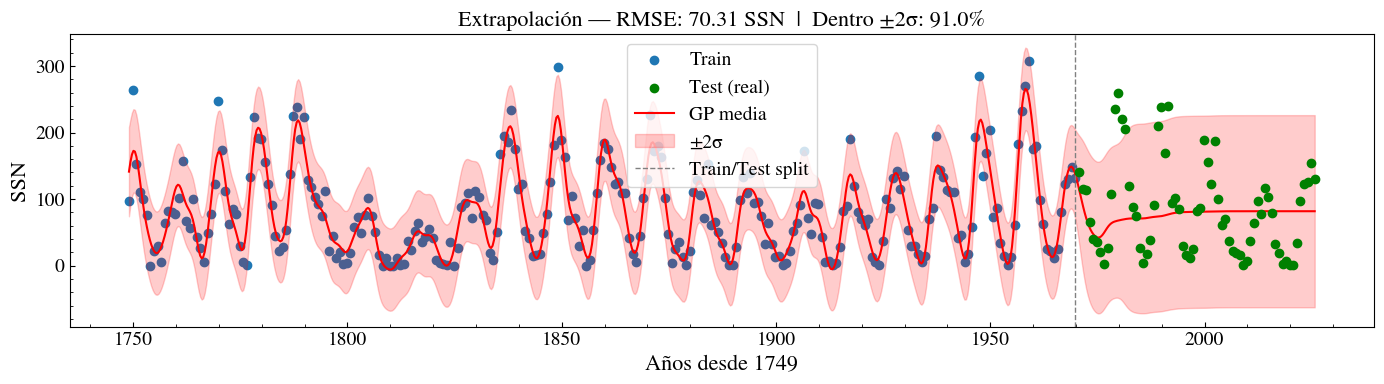

In [25]:
X_pred = np.linspace(X_all.min(), X_all.max(), 800).reshape(-1, 1)
y_mu, y_s = search.best_estimator_.predict(X_pred, return_std=True)

fig, ax = plt.subplots(figsize=(14, 4))
ax.scatter(X_train_extrap, y_train_extrap, color="C0", label="Train")
ax.scatter(X_test_extrap,  y_test_extrap, color="green", zorder=3, label=f"Test (real)")
ax.plot(X_pred, y_mu, color="red", lw=1.5, label="GP media")
ax.fill_between(X_pred.ravel(), y_mu - 2*y_s, y_mu + 2*y_s,
                alpha=0.2, color="red", label="±2σ")
ax.axvline(X_train_extrap.max(), color="gray", ls="--", lw=1, label="Train/Test split")
ax.set_xlabel("Años desde 1749")
ax.set_ylabel("SSN")
ax.set_title(f"Extrapolación — RMSE: {rmse_ext:.2f} SSN  |  Dentro ±2σ: {sigma_ext:.1%}")
ax.legend()
plt.tight_layout()
plt.show()

In [26]:
gp_inter = GaussianProcessRegressor(kernel=search.best_params_["kernel"], n_restarts_optimizer=5, normalize_y=True)
gp_inter.fit(X_train_inter, y_train_inter)
y_pred_int, y_std_int = gp_inter.predict(X_test_inter, return_std=True)

rmse_int       = np.sqrt(np.mean((y_pred_int - y_test_inter)**2))
sigma_int      = np.mean(np.abs(y_pred_int - y_test_inter) < 2 * y_std_int)
print(f"RMSE en interpolación: {rmse_int:.2f} SSN")
print(f"Porcentaje de puntos dentro de ±2σ en interpolación: {sigma_int:.1%}")

RMSE en interpolación: 33.75 SSN
Porcentaje de puntos dentro de ±2σ en interpolación: 92.5%


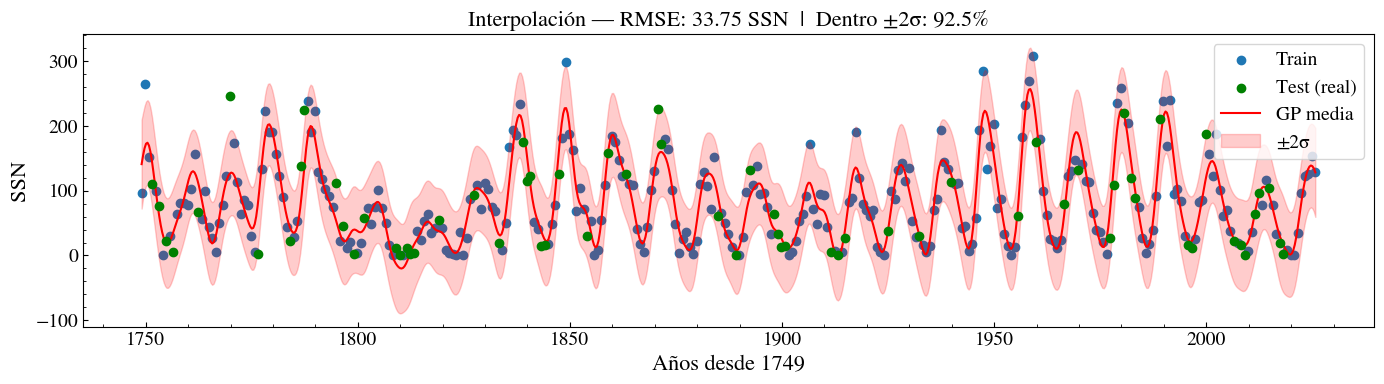

Kernel optimizado: RBF(length_scale=12.2) * ExpSineSquared(length_scale=1.3, periodicity=10.8) + WhiteKernel(noise_level=0.174)
Período GP:           10.78 años
Período Lomb-Scargle: 10.96 años
Diferencia:           0.18 años


In [27]:
X_pred = np.linspace(X_all.min(), X_all.max(), 800).reshape(-1, 1)
y_mu, y_s = gp_inter.predict(X_pred, return_std=True)

fig, ax = plt.subplots(figsize=(14, 4))
ax.scatter(X_train_inter, y_train_inter, color="C0", label="Train")
ax.scatter(X_test_inter,  y_test_inter, color="green", zorder=3, label=f"Test (real)")
ax.plot(X_pred, y_mu, color="red", lw=1.5, label="GP media")
ax.fill_between(X_pred.ravel(), y_mu - 2*y_s, y_mu + 2*y_s,
                alpha=0.2, color="red", label="±2σ")
ax.set_xlabel("Años desde 1749")
ax.set_ylabel("SSN")
ax.set_title(f"Interpolación — RMSE: {rmse_int:.2f} SSN  |  Dentro ±2σ: {sigma_int:.1%}")
ax.legend()
plt.tight_layout()
plt.show()
print("Kernel optimizado:", gp_inter.kernel_)
periodo_gp = gp_inter.kernel_.k1.k2.periodicity
print(f"Período GP:           {periodo_gp:.2f} años")
print(f"Período Lomb-Scargle: {periodo_optimo:.2f} años")
print(f"Diferencia:           {abs(periodo_gp - periodo_optimo):.2f} años")

Qué falta del notebook base (y vale la pena agregar):

Solo dos cosas tienen peso real para este notebook:

ACF de la serie — son 3 líneas y motiva por qué existe estructura periódica antes de cuantificarla con LS. El notebook base lo incluye como primer paso analítico.

Lo que sí sumaría en ese espíritu sería comparar ARIMA vs GP — ambos están en el notebook base, son comparables en complejidad, y la diferencia (ARIMA no extrapola ciclos, GP sí con el kernel correcto) tiene una lección directa.

#	Contenido	Estado	Notas
1	Encabezado y créditos	✅	
2	Introducción: manchas solares y ciclo solar	✅	
3	Carga de datos SIDC	✅	
4	Limpieza y visualización de la serie	✅	Hay un plot redundante antes de la limpieza
5	ACF de la serie solar	❌	Motiva la periodicidad antes de LS
6	Lomb-Scargle + período detectado	✅	10.98 años
7	Derivación matemática del FAP	✅	Buen nivel, tiene glitches de formato LaTeX
8	Cálculo y plot del FAP	✅	
9	Muestras del prior GP	❌	Estándar pedagógico antes de ajustar
10	Diseño del kernel compuesto	✅	
11	Visualización train/test (A y B)	✅	
12	GridSearchCV con TimeSeriesSplit	✅	Ganó Matérn, no el kernel compuesto
13	Evaluación extrapolación + plot	✅	RMSE 69.29, predicción plana
14	Evaluación interpolación + plot	✅	RMSE 31.39, 94% en ±2σ
15	Extracción período del GP	⚠️	Falla si kernel ganador no es periódico
16	Comparación período LS vs GP	⚠️	Código presente pero depende del punto 15
17	Predicción futura	⚠️	Celda print existe, sin plot, resultado plano
18	Celda de conclusión	❌	Responde: ¿cuál es el período del ciclo solar?
19	Celda markdown de feedback (basura)	🗑️	Borrar — es texto de chat pegado como celda
20	GaussianProcessRegressor en imports principales	⚠️	Solo está importado dentro de la celda del CV
21	Idioma consistente	⚠️	Mezcla español/inglés en títulos y ejes
